In [1]:
import pandas as pd
# Librerías para datos y gráficos
import numpy as np          # Para trabajar con arreglos numéricos
import pandas as pd         # Para manejar tablas de datos (DataFrames)
import matplotlib.pyplot as plt  # Para hacer gráficos
import seaborn as sns

from sklearn.feature_selection import chi2

# Herramientas de machine learning (scikit-learn)
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, auc                       # Medir calidad de los modelos
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier  # Modelos de árboles

# Para análisis de supervivencia
from lifelines import KaplanMeierFitter                                       # Para crear curvas de supervivencia
from lifelines.statistics import logrank_test                                 # Prueba para comparar curvas
from sksurv.ensemble import RandomSurvivalForest                              # Modelo de bosque para supervivencia
from sksurv.util import Surv                                                   # Formato de datos para supervivencia
from sksurv.metrics import concordance_index_censored                        # Medida para evaluar modelos de supervivencia

# Para balancear datos y generar muestras nuevas
from imblearn.over_sampling import SMOTE                                   # Para balancear datos desbalanceados

# Para usar XGBoost, un modelo potente basado en árboles
import xgboost as xgb          

from lightgbm import LGBMClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

In [3]:
top25_genes = [
    "CD74",
    "HLA-DPB1",
    "HLA-DRB1",
    "HLA-DMA",
    "HLA-DMB",
    "HLA-DRA",
    "HLA-DPA1",
    "HLA-DOA",
    "HLA-E",
    "HLA-DQA1",
    "PTPRC",
    "LYN",
    "IL10",
    "CD3E",
    "FCGR3A",
    "LCK",
    "CASP1",
    "CD2",
    "B2M",
    "LCP2",
    "SERPING1",
    "CD4",
    "FCER1G",
    "C1QB",
    "C1QC"
]

In [4]:
path_rppa = '../data/Human__TCGA_LGG__MDA__RPPA__MDA_RPPA__01_28_2016__BI__Gene__Firehose_RPPA.cct.txt'
path_mutation = '../data/Human__TCGA_LGG__WUSM__Mutation__GAIIx__01_28_2016__BI__Gene__Firehose_MutSig2CV.cbt.txt'

path_scna_gen = '../data/Human__TCGA_LGG__BI__SCNA__SNP_6.0__01_28_2016__BI__Gene__Firehose_GISTIC2.cct'

rppa = pd.read_csv(path_rppa, sep='\t', index_col=0)
muta = pd.read_csv(path_mutation, sep='\t', index_col=0)
scna_gen = pd.read_csv(path_scna_gen, sep='\t', index_col=0)

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

Dimensión datos rppa: (148, 429)
Dimensión datos mutaciones: (889, 513)
Dimensión datos scna: (24776, 513)


In [5]:
rppa = rppa.loc[rppa.index.isin(top25_genes)]
scna_gen = scna_gen.loc[scna_gen.index.isin(top25_genes)]
muta = muta.loc[muta.index.isin(top25_genes)]

print(f"Dimensión datos rppa: {rppa.shape}")  # espera genes x muestras
print(f"Dimensión datos mutaciones: {muta.shape}")
print(f"Dimensión datos scna: {scna_gen.shape}")

print(scna_gen.index.tolist())

Dimensión datos rppa: (1, 429)
Dimensión datos mutaciones: (1, 513)
Dimensión datos scna: (16, 513)
['C1QC', 'C1QB', 'LCK', 'CD2', 'FCER1G', 'FCGR3A', 'PTPRC', 'IL10', 'CD74', 'LCP2', 'LYN', 'SERPING1', 'CASP1', 'CD3E', 'CD4', 'B2M']


In [8]:
scna_gen = scna_gen.T 
scna_gen.head()

attrib_name,C1QC,C1QB,LCK,CD2,FCER1G,FCGR3A,PTPRC,IL10,CD74,LCP2,LYN,SERPING1,CASP1,CD3E,CD4,B2M
TCGA.CS.4938,0.004,0.004,0.004,0.003,0.003,0.003,0.003,0.003,-0.002,-0.002,-0.003,-0.001,-0.001,-0.001,0.067,0.007
TCGA.CS.4941,0.459,0.459,0.459,0.447,0.447,0.447,0.444,0.444,0.003,0.003,-0.015,-0.018,-0.014,-0.014,0.004,-0.027
TCGA.CS.4942,0.002,0.002,0.002,0.002,0.002,0.002,0.002,0.002,-0.019,-0.019,0.000,0.001,0.004,0.004,0.017,0.004
TCGA.CS.4943,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,-0.043,0.005,0.005,-0.007,0.016,0.001,0.001,1.628,0.056
TCGA.CS.4944,-0.009,-0.009,-0.009,-0.691,0.000,0.000,0.000,0.000,0.008,0.008,-0.002,-0.005,0.004,0.004,0.005,-0.011


In [9]:
data_cox = pd.read_csv('../data/data_cox_with_survival3yr_ht.csv', index_col=0)
data_cox.head()


,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.4117,3.8538,9.7537,234.0,True,-2.580570,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1,1.0,0.0,0.0


In [10]:
# Renombrar columnas de scna_gen para indicar origen "_scna"
scna_renamed = scna_gen.add_suffix('_scna')

# Renombrar columnas de data_cox para indicar origen "_expression"
cox_renamed = data_cox.add_suffix('_expression')

# Mantener la columna survival_3yr sin sufijo, directamente desde data_cox
survival_col = data_cox['survival_3yr']

# Encontrar genes comunes basados en nombres base sin sufijo
genes_cox = set([col.replace('_expression', '') for col in cox_renamed.columns])
genes_scna = set([col.replace('_scna', '') for col in scna_renamed.columns])
common_genes = genes_cox.intersection(genes_scna)

# Columnas para filtrar
cols_cox_common = [gene + '_expression' for gene in common_genes]
cols_scna_common = [gene + '_scna' for gene in common_genes]

# Filtrado de columnas para genes comunes
cox_filtered = cox_renamed[cols_cox_common]
scna_filtered = scna_renamed[cols_scna_common]

# Unir los datos por índice (muestras)
merged_data = pd.merge(cox_filtered, scna_filtered, left_index=True, right_index=True, how='inner')

# Añadir la columna survival_3yr de data_cox (sin sufijo)
merged_data = merged_data.join(survival_col, how='inner')

# Ordenar columnas para que cada gen tenga expresión y SCNA lado a lado
ordered_cols = []
for gene in sorted(common_genes):
    ordered_cols.append(gene + '_expression')
    ordered_cols.append(gene + '_scna')
ordered_cols.append('survival_3yr')

merged_data = merged_data[ordered_cols]

merged_data.head()


,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LCK_scna,LCP2_expression,LCP2_scna,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,0.004,7.6154,-0.002,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0.459,9.0451,0.003,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,0.002,9.2850,-0.019,10.4678,0.000,10.3002,0.002,9.8687,0.001,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,-0.043,7.9089,0.005,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,-0.009,6.9549,0.008,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1


In [46]:
data_cox.head()

,CD74,HLA-DPB1,HLA-DRB1,HLA-DMA,HLA-DMB,HLA-DRA,HLA-DPA1,HLA-DOA,HLA-E,HLA-DQA1,...,COL1A1,CD80,CD163,overall_survival,status,risk_score,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,12.5668,8.6102,8.7590,8.5993,8.9834,10.7880,8.8908,6.8782,12.2597,6.8204,...,5.7512,0.5055,6.8627,3574.0,False,-7.832610,1,1.0,0.0,0.0
TCGA.CS.4941,15.4927,11.9222,12.3668,10.5364,10.8081,13.9021,12.5162,10.0694,13.9244,10.2799,...,8.4117,3.8538,9.7537,234.0,True,-2.580570,0,1.0,0.0,0.0
TCGA.CS.4942,15.3739,11.4483,12.7477,10.5580,10.8706,13.7942,11.9650,10.3466,13.7275,10.4735,...,5.8167,2.9856,8.9766,1335.0,True,-3.892725,1,1.0,0.0,0.0
TCGA.CS.4943,13.2865,10.4928,9.8587,9.0924,9.5139,11.8657,10.5019,8.5010,11.6388,8.4154,...,8.6443,1.7148,8.7332,1106.0,True,-6.731689,1,1.0,0.0,0.0
TCGA.CS.4944,14.4549,11.6700,11.6364,10.3967,9.8603,13.2601,11.5003,9.0541,12.5336,9.8875,...,4.6267,0.0000,9.8959,1828.0,False,-4.565826,1,1.0,0.0,0.0


In [47]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LCK_scna,LCP2_expression,LCP2_scna,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,0.004,7.6154,-0.002,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,0.459,9.0451,0.003,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,0.002,9.2850,-0.019,10.4678,0.000,10.3002,0.002,9.8687,0.001,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,-0.043,7.9089,0.005,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,-0.009,6.9549,0.008,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1


In [48]:
# Selecciona las columnas histológicas codificadas
hist_cols = [col for col in data_cox.columns if col.startswith('histological_type')]

# Une las columnas histológicas a merged_data (por índice)
merged_data = merged_data.join(data_cox[hist_cols], how='inner')

In [49]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,survival_3yr,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1,1.0,0.0,0.0
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,0,1.0,0.0,0.0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,10.4678,0.000,10.3002,0.002,9.8687,0.001,1,1.0,0.0,0.0
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1,1.0,0.0,0.0
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1,1.0,0.0,0.0


In [50]:
# Mover la columna 'survival_3yr' al final del DataFrame
cols = [col for col in merged_data.columns if col != 'survival_3yr'] + ['survival_3yr']
merged_data = merged_data[cols]


In [51]:
merged_data.head()

,B2M_expression,B2M_scna,C1QB_expression,C1QB_scna,C1QC_expression,C1QC_scna,CASP1_expression,CASP1_scna,CD2_expression,CD2_scna,...,LYN_expression,LYN_scna,PTPRC_expression,PTPRC_scna,SERPING1_expression,SERPING1_scna,histological_type_astrocytoma,histological_type_oligoastrocytoma,histological_type_oligodendroglioma,survival_3yr
TCGA.CS.4938,14.0208,0.007,11.3329,0.004,11.2728,0.004,7.3958,-0.001,1.6312,0.003,...,8.9073,-0.003,7.9303,0.003,8.2515,-0.001,1.0,0.0,0.0,1
TCGA.CS.4941,15.7253,-0.027,12.5445,0.459,12.4334,0.459,8.4219,-0.014,6.5359,0.447,...,10.5100,-0.015,9.5845,0.444,11.8442,-0.018,1.0,0.0,0.0,0
TCGA.CS.4942,15.6693,0.004,13.3568,0.002,13.2014,0.002,8.5825,0.004,4.3971,0.002,...,10.4678,0.000,10.3002,0.002,9.8687,0.001,1.0,0.0,0.0,1
TCGA.CS.4943,13.6961,0.056,11.8849,-0.043,11.9314,-0.043,7.1080,0.001,2.3893,-0.043,...,8.7019,-0.007,8.2115,-0.043,7.9684,0.016,1.0,0.0,0.0,1
TCGA.CS.4944,14.4556,-0.011,11.4629,-0.009,11.5642,-0.009,7.0236,0.004,3.9186,-0.691,...,8.1417,-0.002,7.2412,0.000,10.4694,-0.005,1.0,0.0,0.0,1


## EDA

In [52]:
# General info
print("Resumen de tipos de datos y valores no nulos:")
print(merged_data.info())

print("\nDescriptivo general:")
print(merged_data.describe(include='all'))

print("\nPrimeras filas del DataFrame:")
print(merged_data.head())

print("\nConteo de valores para la variable objetivo:")
print(merged_data['survival_3yr'].value_counts())

Resumen de tipos de datos y valores no nulos:
<class 'pandas.core.frame.DataFrame'>
Index: 478 entries, TCGA.CS.4938 to TCGA.WY.A85E
Data columns (total 36 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   B2M_expression                       478 non-null    float64
 1   B2M_scna                             478 non-null    float64
 2   C1QB_expression                      478 non-null    float64
 3   C1QB_scna                            478 non-null    float64
 4   C1QC_expression                      478 non-null    float64
 5   C1QC_scna                            478 non-null    float64
 6   CASP1_expression                     478 non-null    float64
 7   CASP1_scna                           478 non-null    float64
 8   CD2_expression                       478 non-null    float64
 9   CD2_scna                             478 non-null    float64
 10  CD3E_expression                      

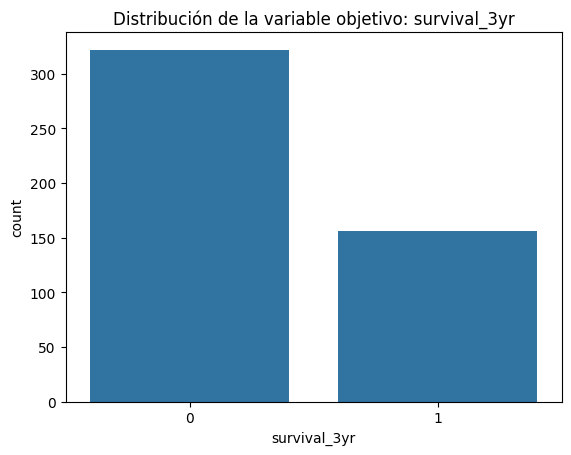

In [53]:
# Visualización de la variable objetivo
sns.countplot(x='survival_3yr', data=merged_data)
plt.title('Distribución de la variable objetivo: survival_3yr')
plt.show()

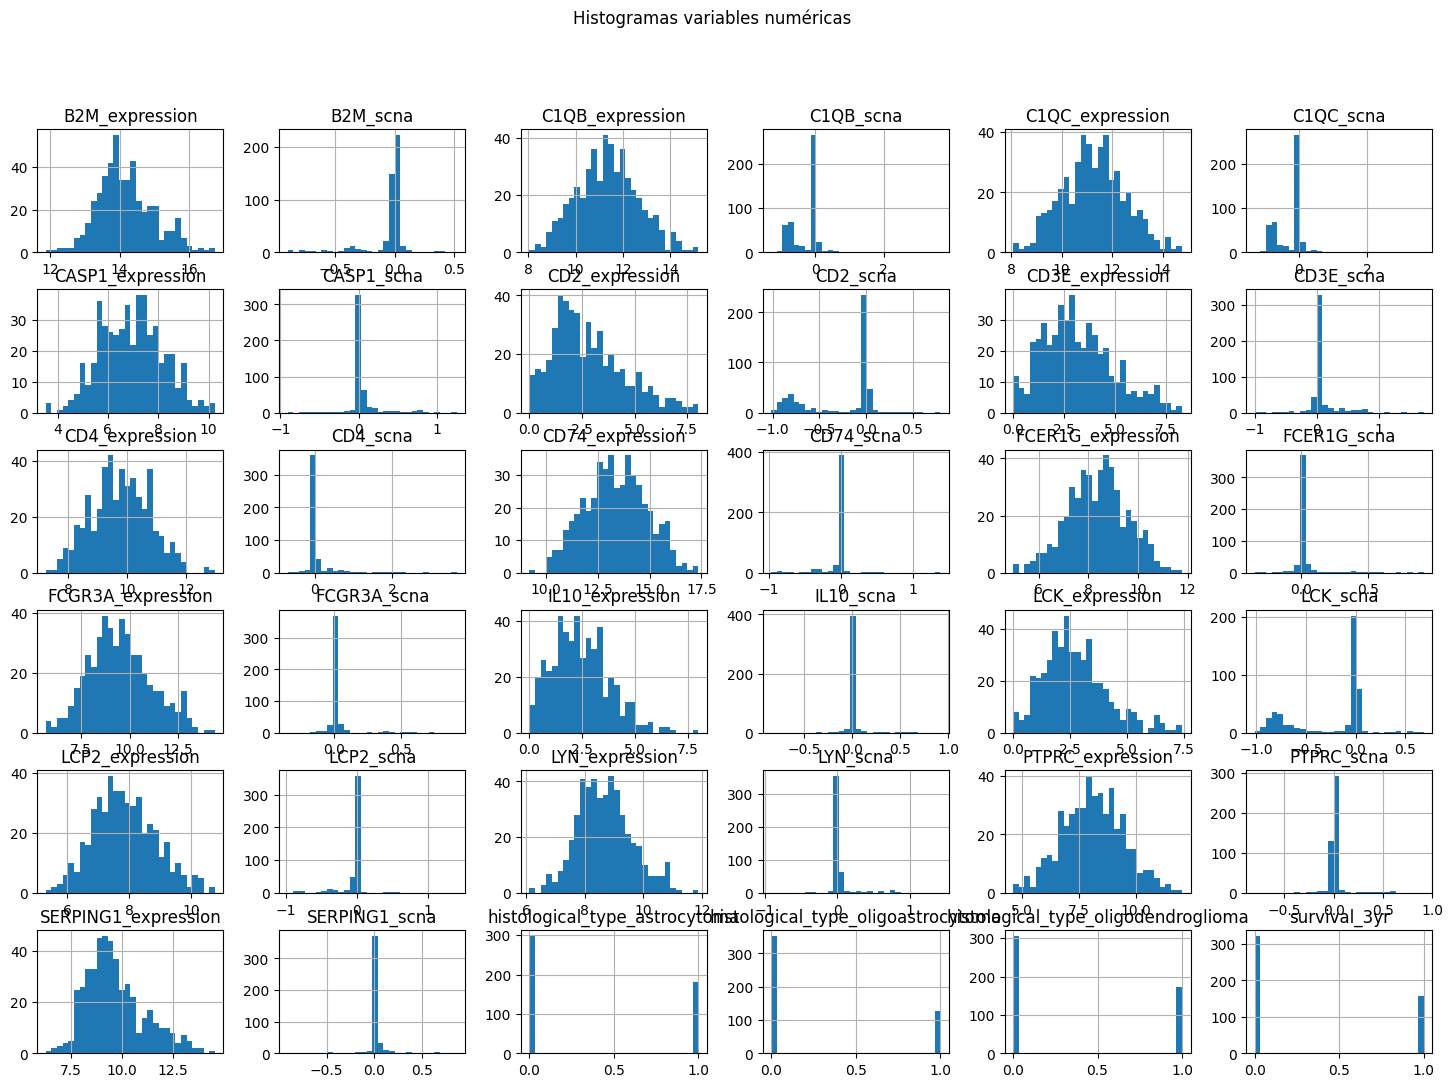

In [54]:
merged_data.hist(bins=30, figsize=(18, 12))
plt.suptitle('Histogramas variables numéricas')
plt.show()

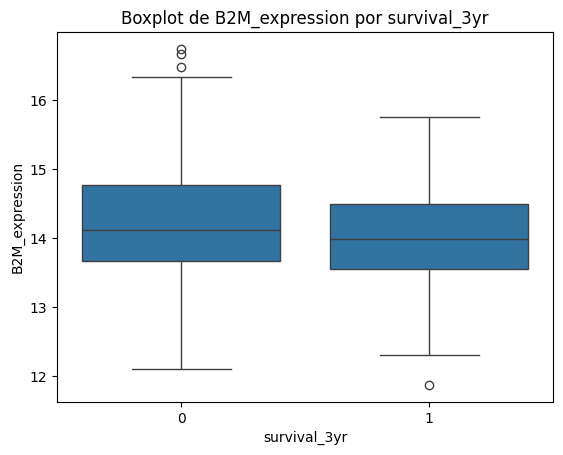

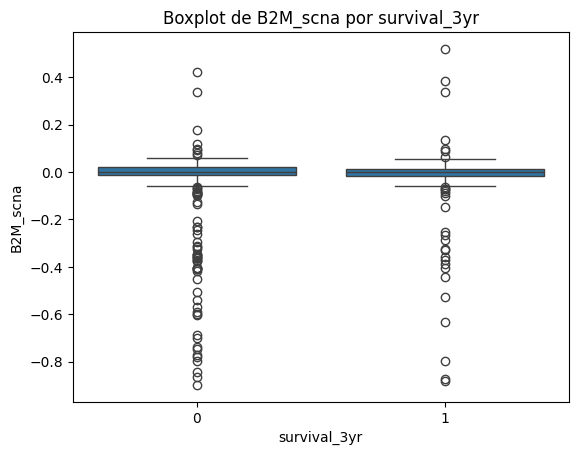

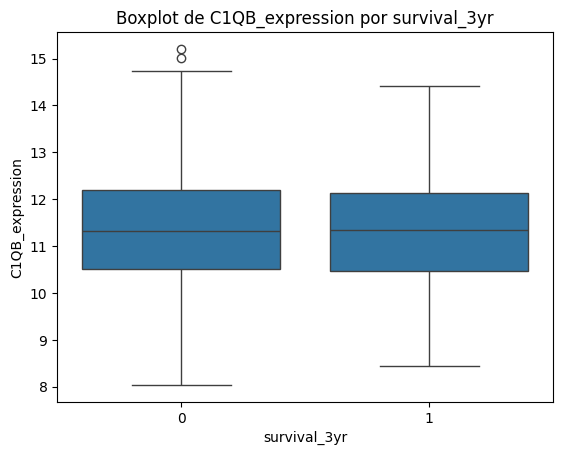

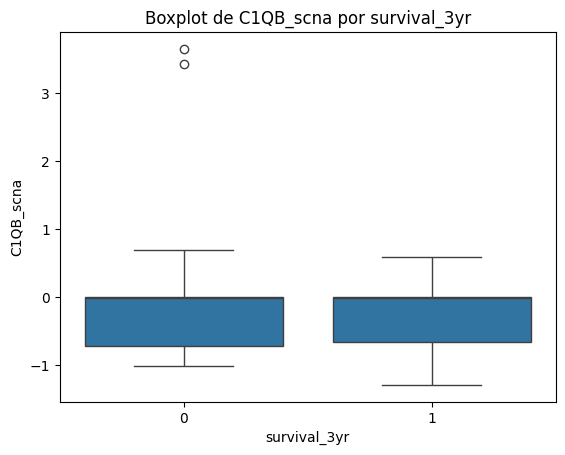

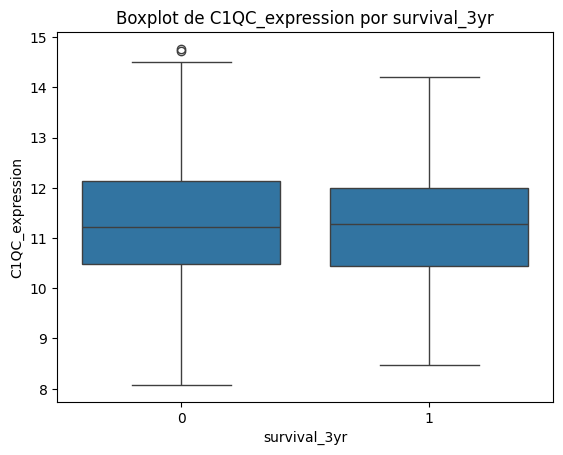

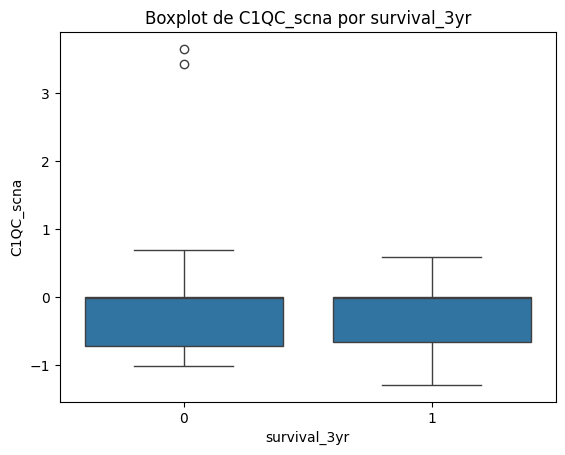

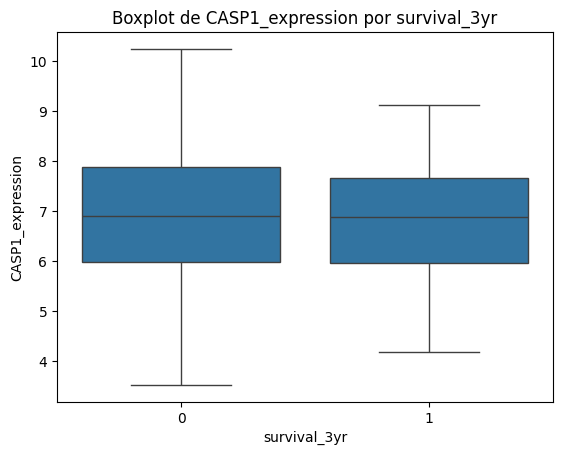

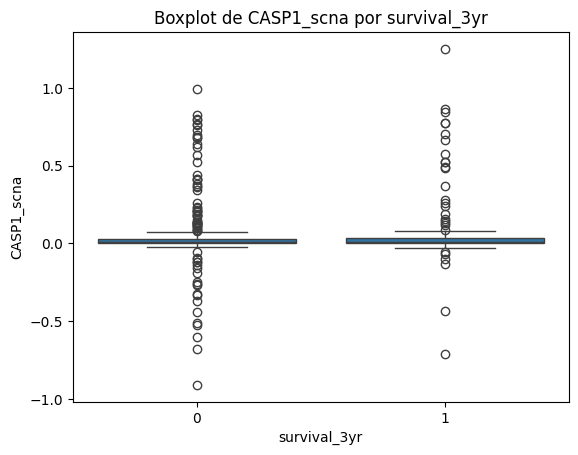

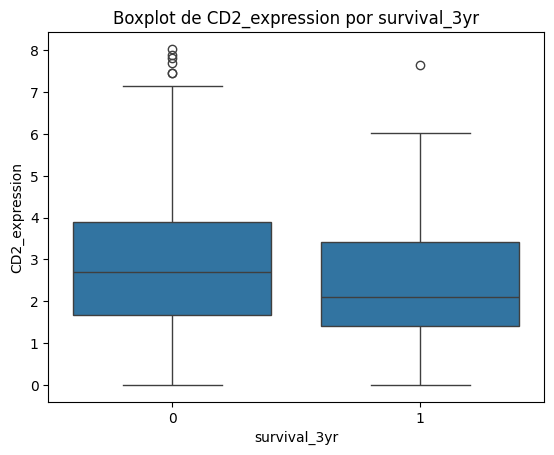

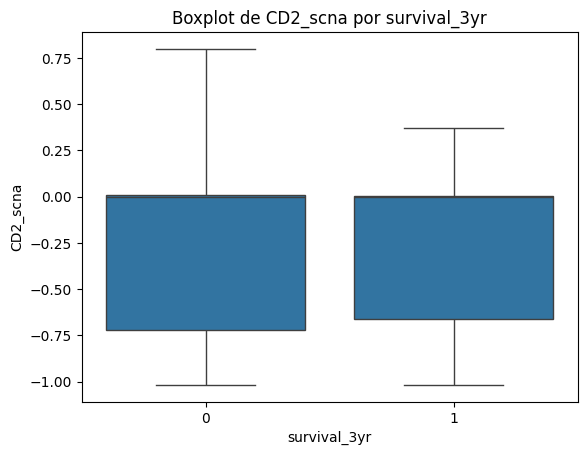

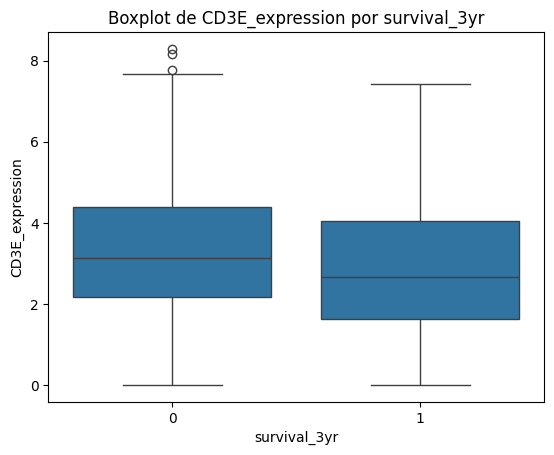

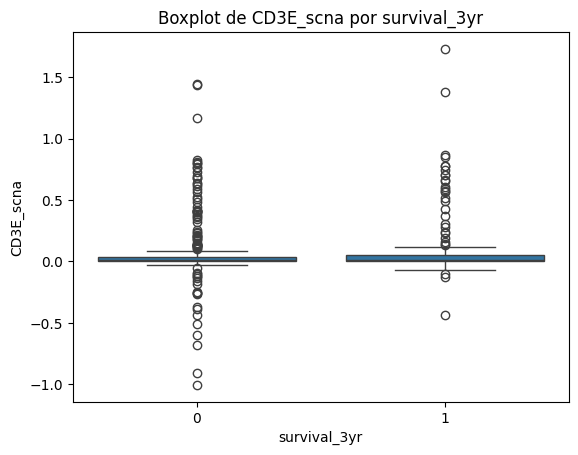

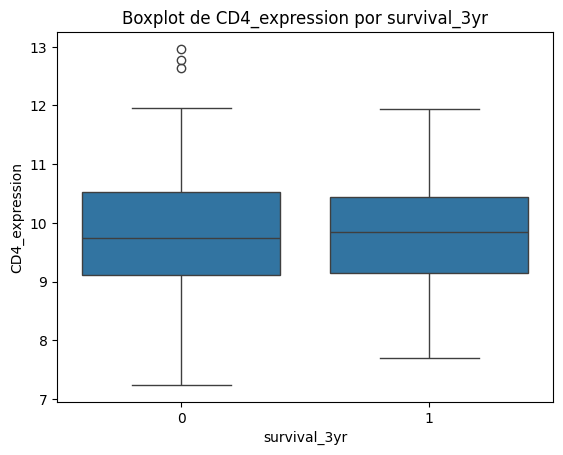

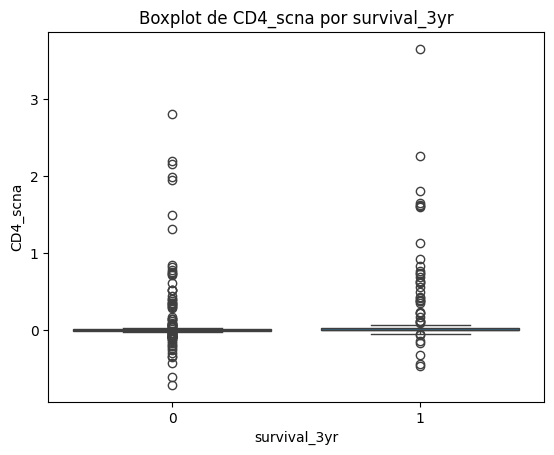

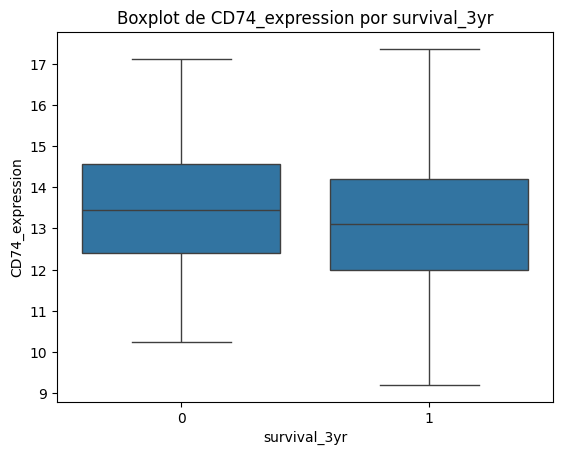

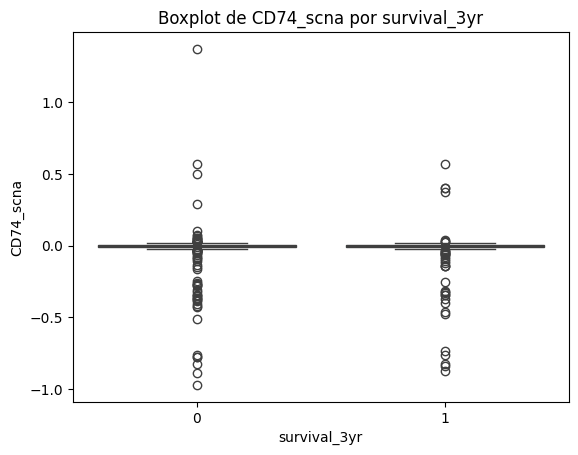

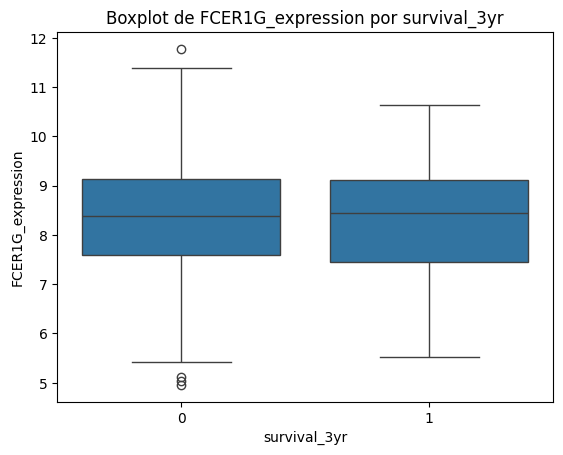

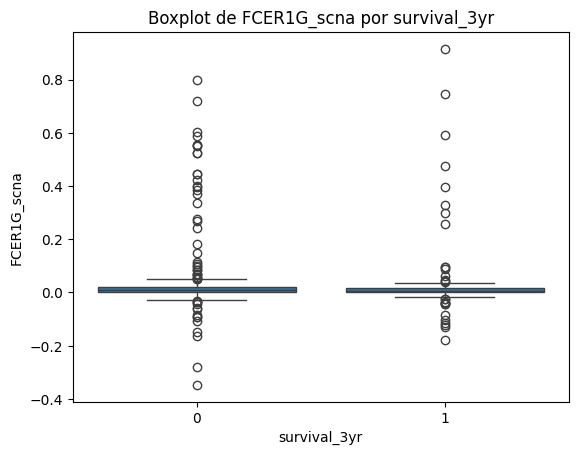

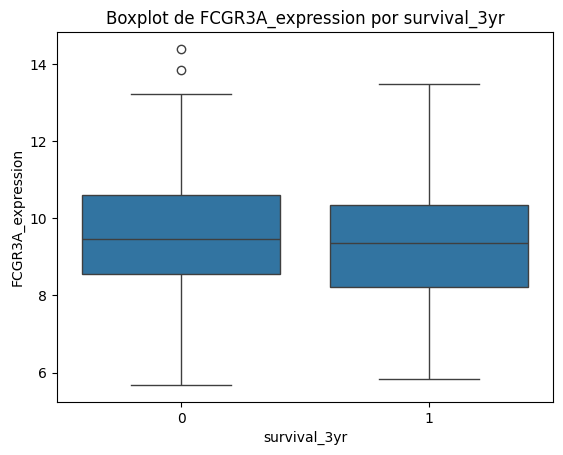

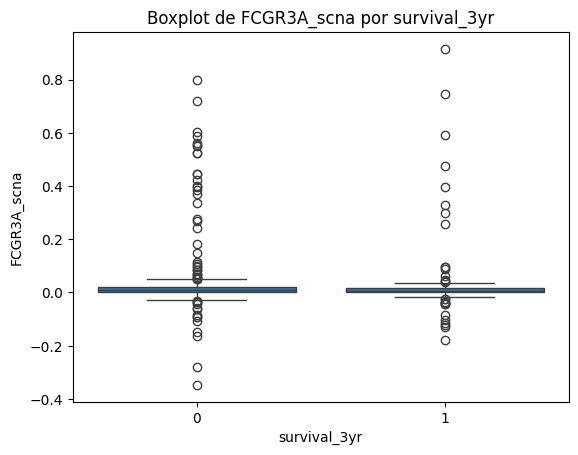

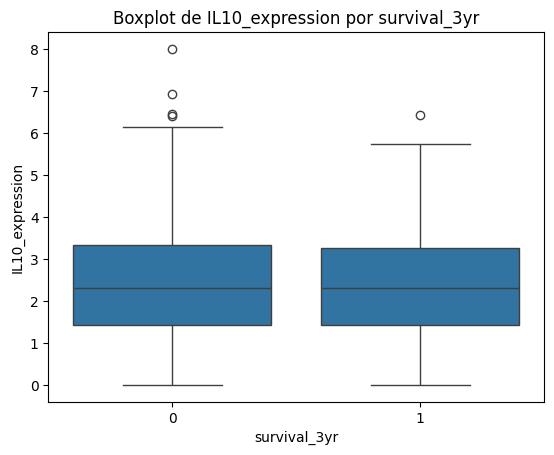

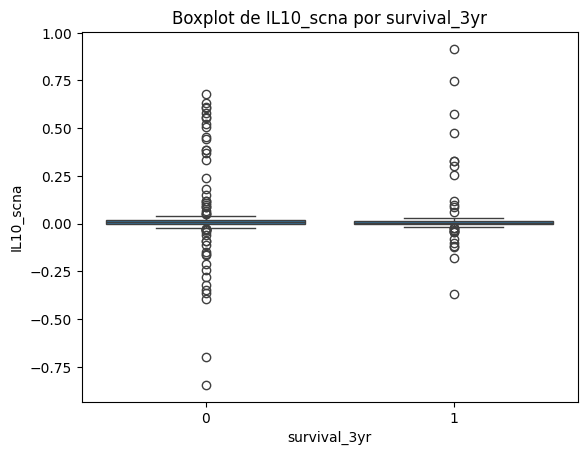

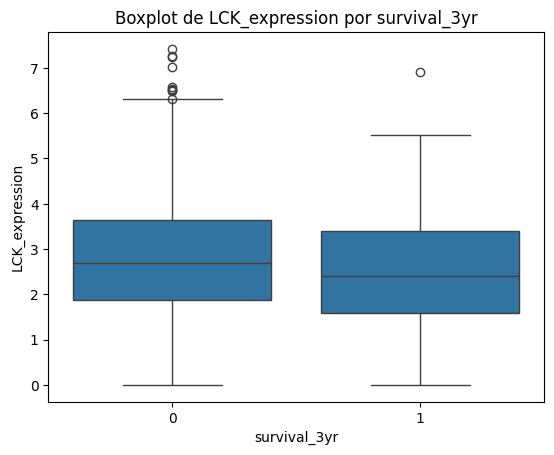

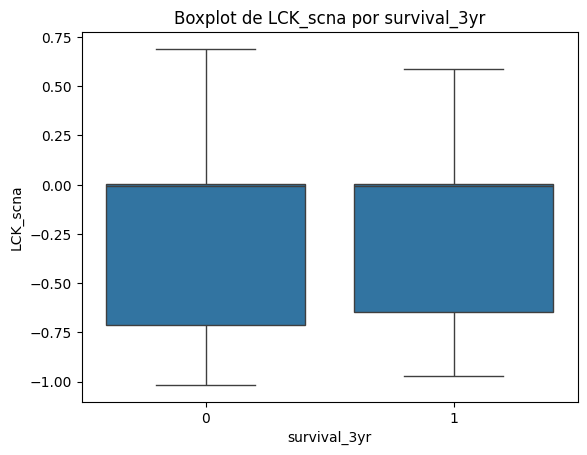

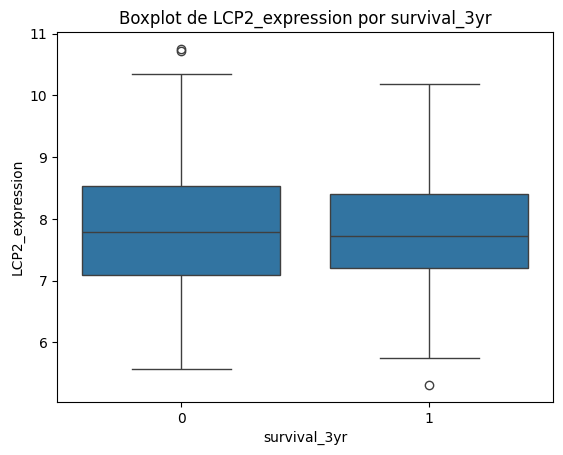

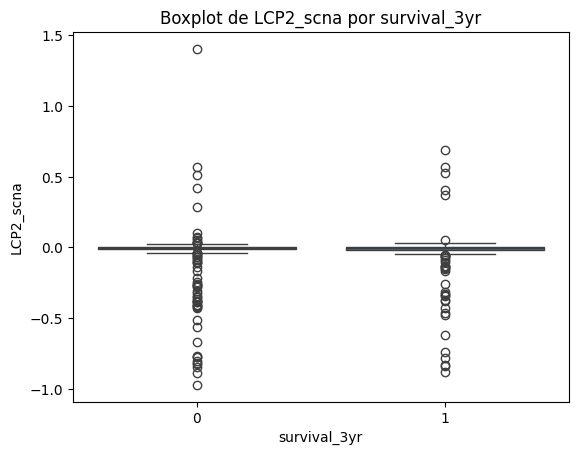

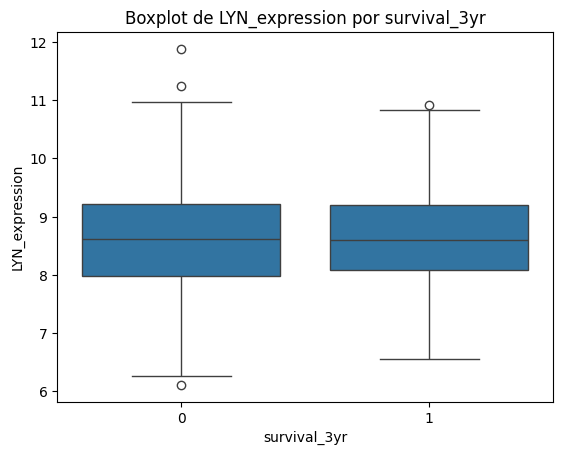

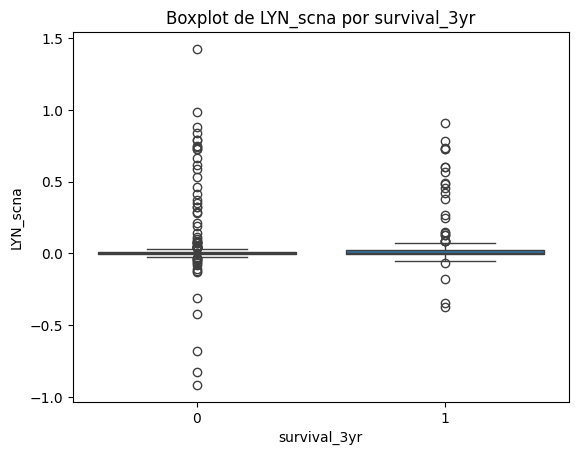

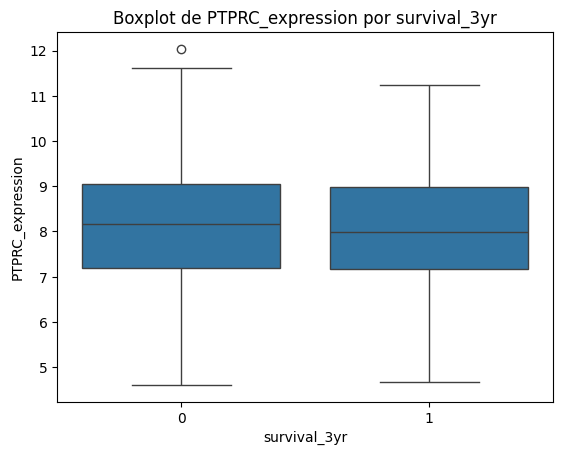

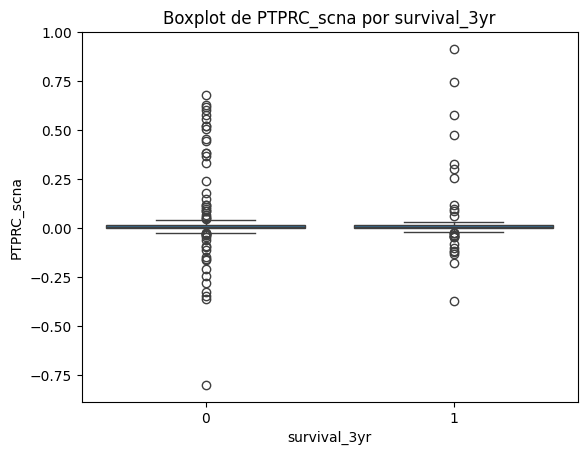

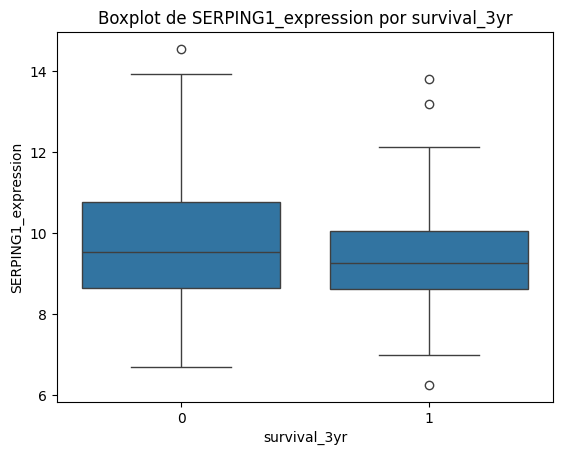

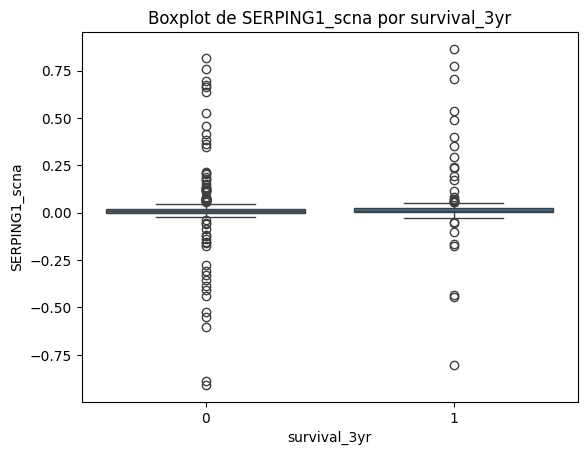

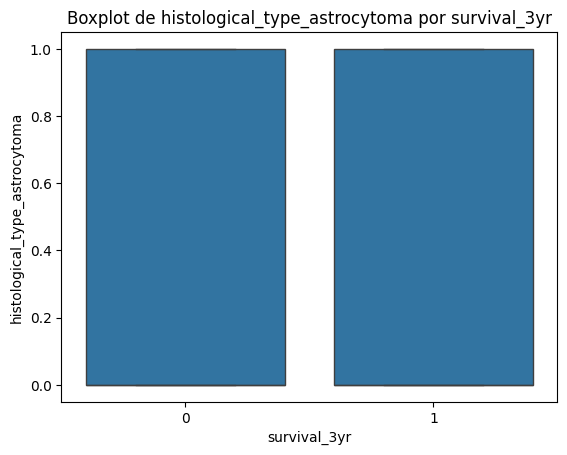

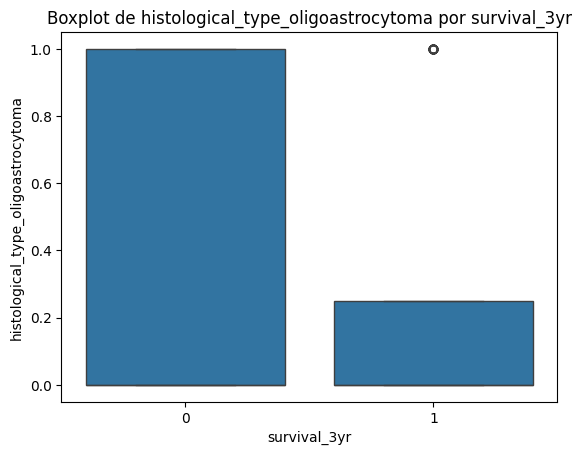

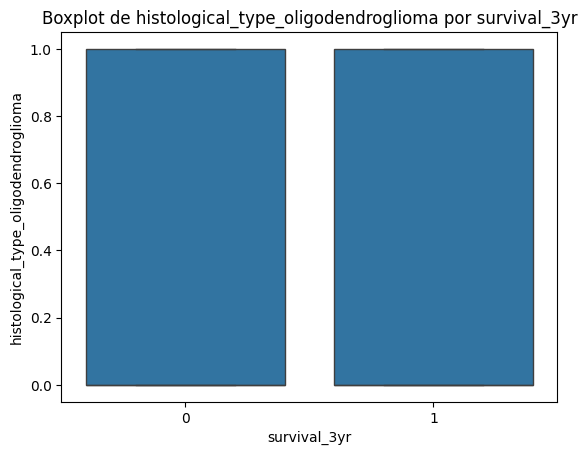

In [55]:
# Boxplots para variables numéricas vs target
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
for col in num_cols:
    if col != 'survival_3yr':
        sns.boxplot(x='survival_3yr', y=col, data=merged_data)
        plt.title(f'Boxplot de {col} por survival_3yr')
        plt.show()

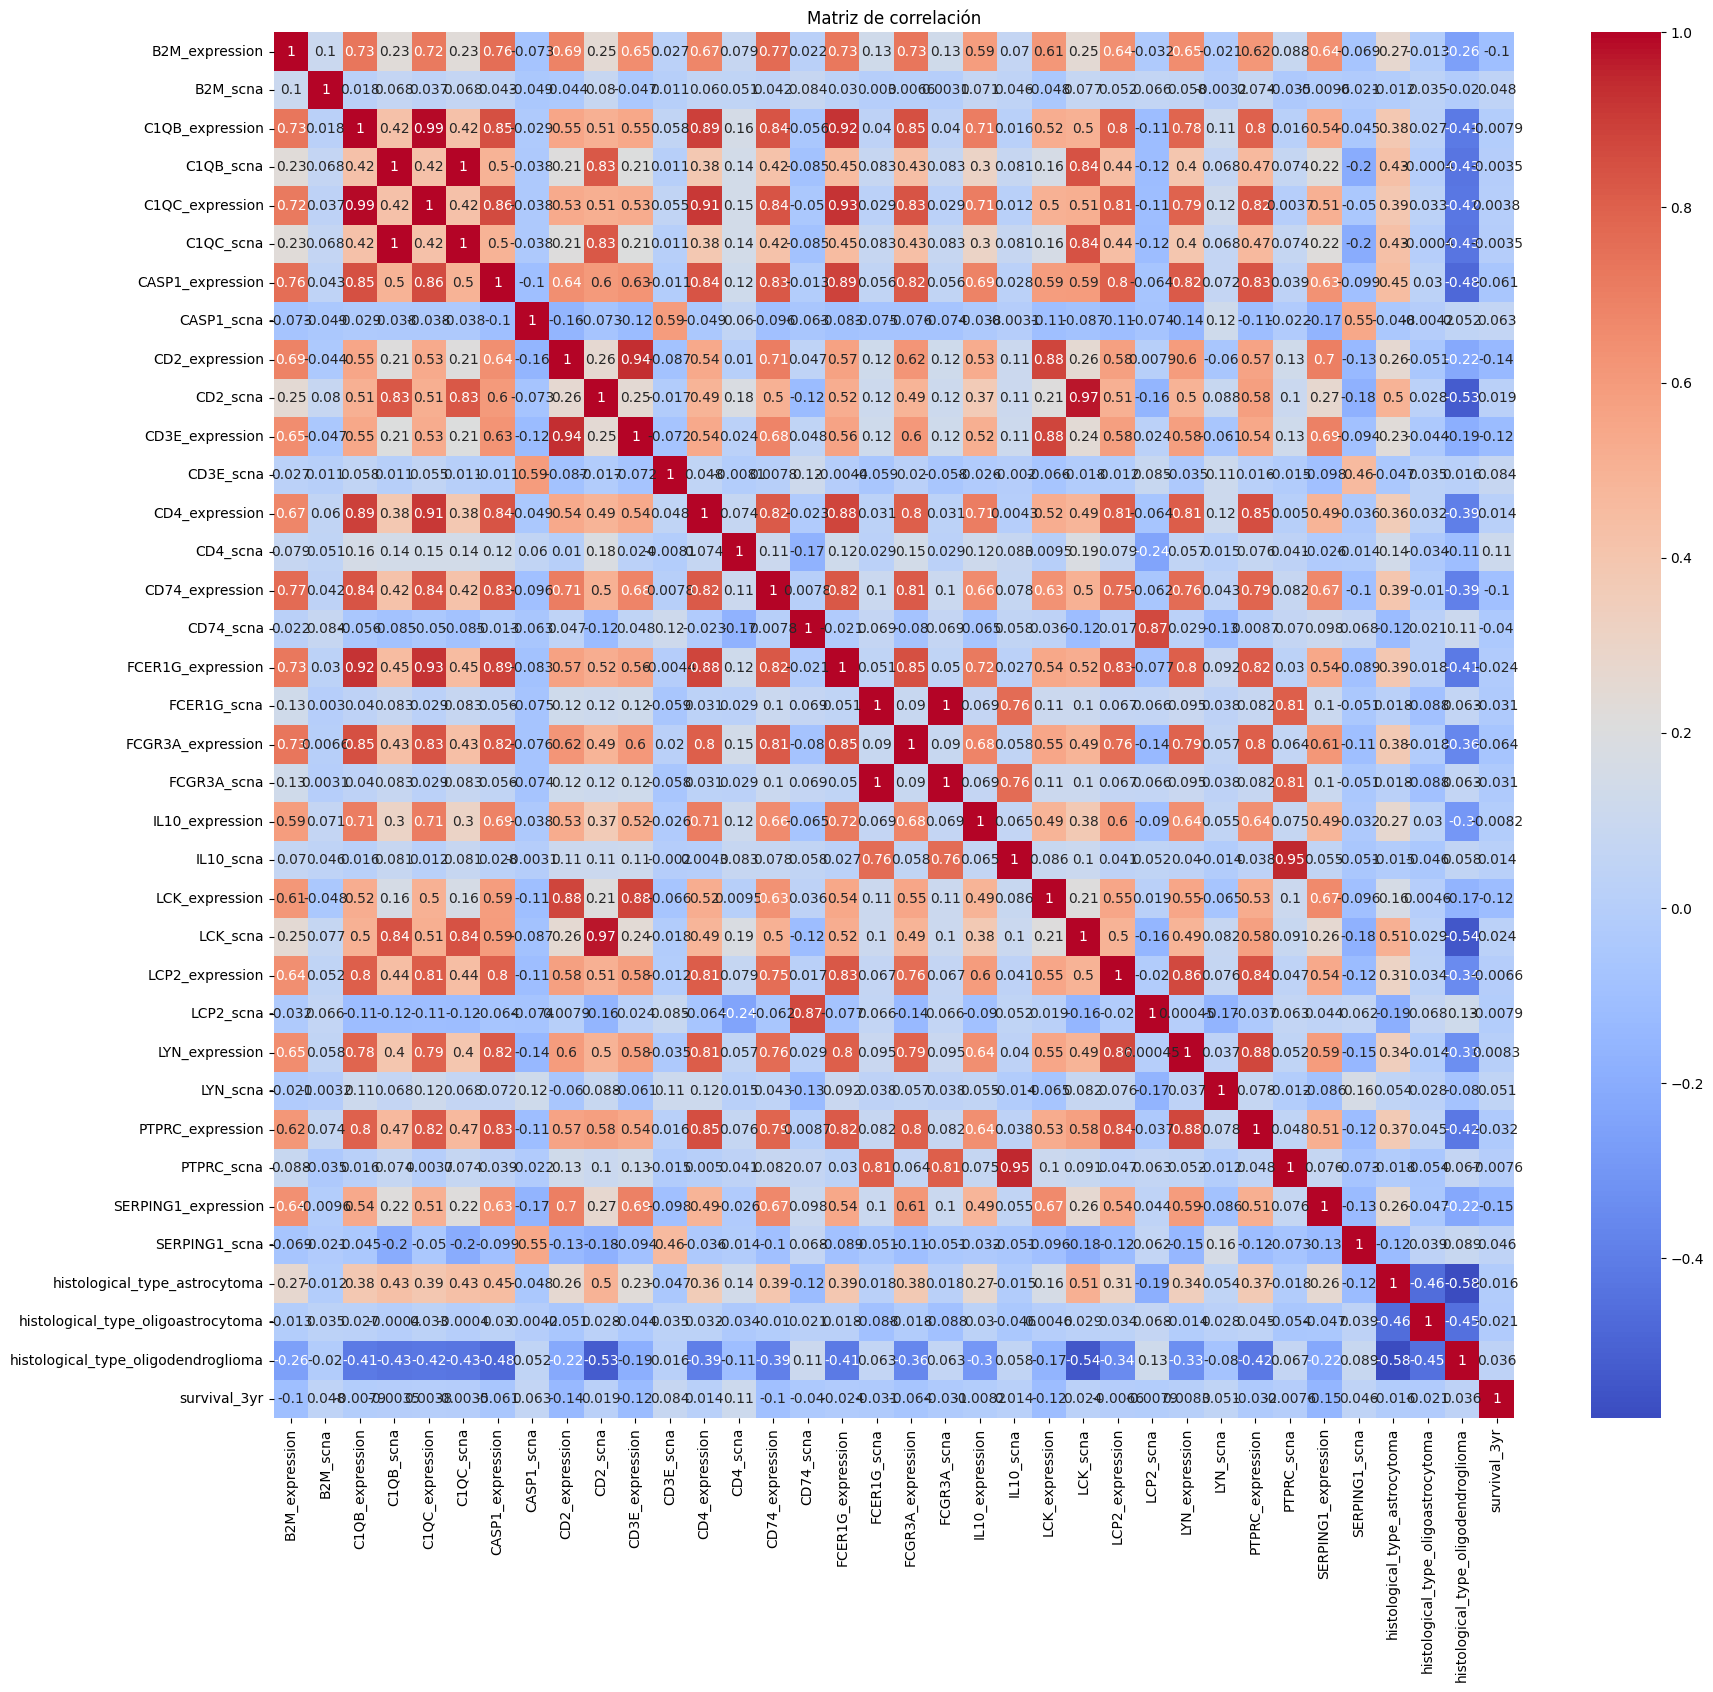

In [56]:
# Correlación de variables numéricas
plt.figure(figsize=(20, 18))
sns.heatmap(merged_data[num_cols].corr(), annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()


Valor de conteos en histological_type_astrocytoma:
histological_type_astrocytoma
0.0    298
1.0    180
Name: count, dtype: int64


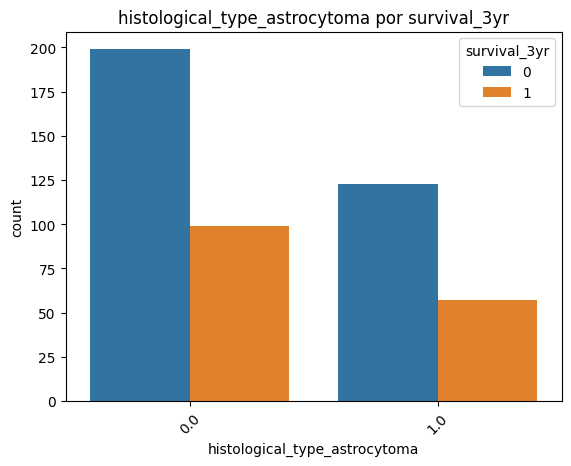


Valor de conteos en histological_type_oligoastrocytoma:
histological_type_oligoastrocytoma
0.0    352
1.0    126
Name: count, dtype: int64


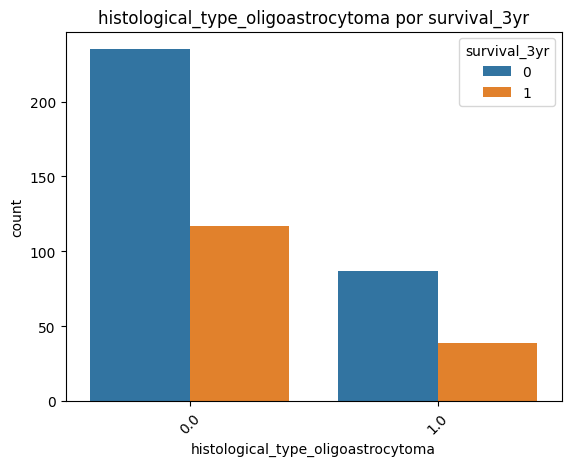


Valor de conteos en histological_type_oligodendroglioma:
histological_type_oligodendroglioma
0.0    306
1.0    172
Name: count, dtype: int64


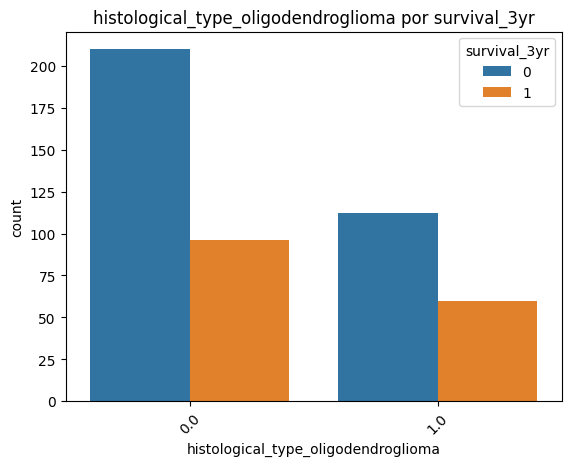

In [57]:
# Filtrar columnas que empiezan con 'histological_type'
hist_cols = [col for col in merged_data.columns if col.startswith('histological_type')]

for col in hist_cols:
    print(f"\nValor de conteos en {col}:")
    print(merged_data[col].value_counts())
    sns.countplot(x=col, data=merged_data, hue='survival_3yr')
    plt.title(f'{col} por survival_3yr')
    plt.xticks(rotation=45)
    plt.show()


In [58]:
#Correlación de Pearson para variables numéricas
num_cols = merged_data.select_dtypes(include=['float64', 'int']).columns
if 'survival_3yr' in num_cols:
    num_cols = num_cols.drop('survival_3yr')  # Evita autoco-correlación

correlations = merged_data[num_cols].corrwith(merged_data['survival_3yr']).abs().sort_values(ascending=False)
print("Correlaciones con survival_3yr:")
print(correlations)

Correlaciones con survival_3yr:
SERPING1_expression                    0.150260
CD2_expression                         0.137251
CD3E_expression                        0.122465
LCK_expression                         0.115116
CD4_scna                               0.112023
B2M_expression                         0.104827
CD74_expression                        0.100040
CD3E_scna                              0.084048
FCGR3A_expression                      0.064053
CASP1_scna                             0.062536
CASP1_expression                       0.061232
LYN_scna                               0.050605
B2M_scna                               0.047611
SERPING1_scna                          0.046335
CD74_scna                              0.040278
histological_type_oligodendroglioma    0.035941
PTPRC_expression                       0.032037
FCGR3A_scna                            0.031056
FCER1G_scna                            0.030999
LCK_scna                               0.024439
FCER1G_e

In [59]:
#Importancia según RandomForest (considerando todas las variables)
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# Ya no aplicamos get_dummies porque las columnas histological_type ya están como one-hot
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

importancias = pd.Series(rf.feature_importances_, index=X.columns)
importancias = importancias.sort_values(ascending=False)
print("Importancia según RandomForest:")
print(importancias)

Importancia según RandomForest:
SERPING1_expression                    0.053867
CD4_scna                               0.043239
CD74_expression                        0.042060
CD2_expression                         0.038690
FCER1G_expression                      0.037501
IL10_expression                        0.034978
CD3E_scna                              0.034553
LYN_expression                         0.034411
LYN_scna                               0.034051
CD4_expression                         0.033936
CD3E_expression                        0.033430
FCGR3A_expression                      0.033176
PTPRC_expression                       0.032547
LCP2_expression                        0.031609
LCP2_scna                              0.030097
CD74_scna                              0.028742
LCK_expression                         0.028647
SERPING1_scna                          0.028190
B2M_scna                               0.028129
CASP1_scna                             0.027966
FCER1G_s

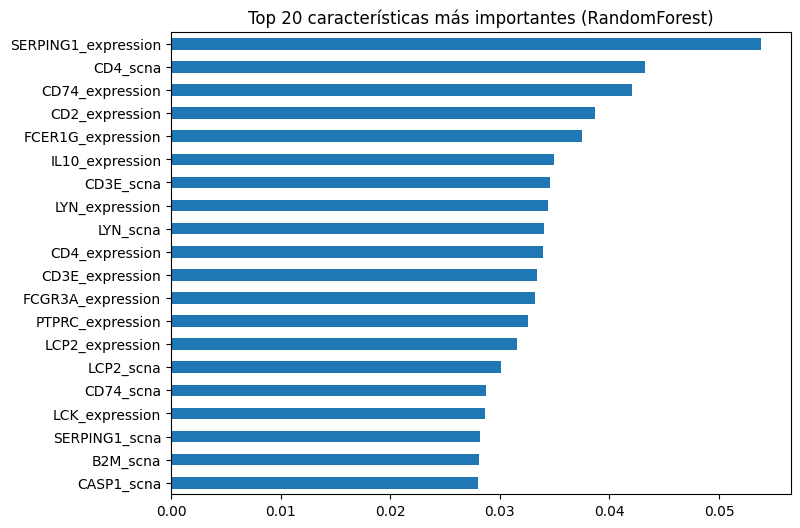

In [60]:
# Visualización
importancias.head(20).plot(kind='barh', figsize=(8, 6))
plt.title('Top 20 características más importantes (RandomForest)')
plt.gca().invert_yaxis()
plt.show()

In [61]:
#Chi-cuadrado para variables categóricas (one-hot de histological_type)

if hist_cols:
    chi_scores = chi2(merged_data[hist_cols], y)
    chi2_df = pd.DataFrame({'Feature': hist_cols, 'Chi2 Score': chi_scores[0]})
    chi2_df = chi2_df.sort_values('Chi2 Score', ascending=False)
    print("Chi-cuadrado para variables histological_type:")
    print(chi2_df.head(10))
else:
    print("No se encontraron columnas que empiecen con 'histological_type' para análisis chi-cuadrado.")

Chi-cuadrado para variables histological_type:
                               Feature  Chi2 Score
2  histological_type_oligodendroglioma    0.395271
1   histological_type_oligoastrocytoma    0.162452
0        histological_type_astrocytoma    0.076927


## Modelos

In [62]:
# Función para evaluar modelo y obtener AUC
def evaluar_modelo(modelo, X, y, cv):
    auc_scores = []
    for train_idx, test_idx in cv.split(X, y):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        modelo.fit(X_train, y_train)
        y_proba = modelo.predict_proba(X_test)[:, 1]
        auc = roc_auc_score(y_test, y_proba)
        auc_scores.append(auc)

    return auc_scores, y_test, y_proba

In [63]:
X = merged_data.drop('survival_3yr', axis=1)
y = merged_data['survival_3yr']

# aumento de la data con SMOTE
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

X = X_resampled.values
y = y_resampled.values

# validacion cruzada
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

[LightGBM] [Info] Number of positive: 257, number of negative: 258
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001213 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 4759
[LightGBM] [Info] Number of data points in the train set: 515, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.499029 -> initscore=-0.003884
[LightGBM] [Info] Start training from score -0.003884
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


[LightGBM] [Info] Number of positive: 258, number of negative: 258
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000237 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4810
[LightGBM] [Info] Number of data points in the train set: 516, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

d:\Coding\investigacionIA\entorno\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


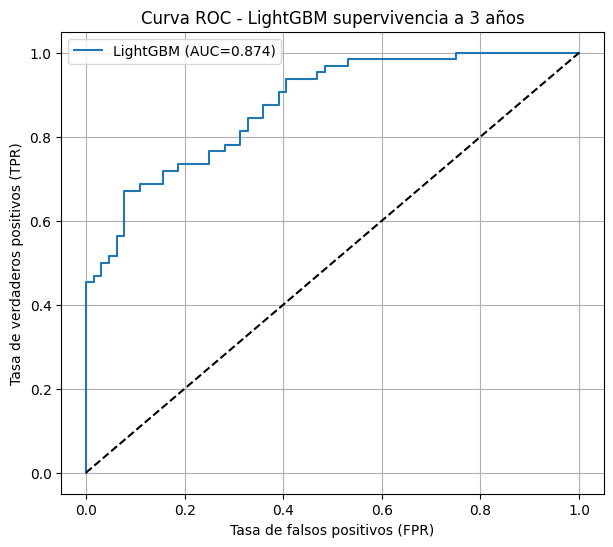

In [64]:
lgbm_clf = LGBMClassifier(random_state=42, colsample_bytree=1.0, learning_rate=0.2, max_depth=7, n_estimators=200, num_leaves=31, subsample=0.8)

# Evaluar LightGBM
auc_lgbm, y_test_lgbm, y_proba_lgbm = evaluar_modelo(lgbm_clf, X, y, cv)
print(f"AUC ROC promedio LightGBM (default): {np.mean(auc_lgbm):.4f} ± {np.std(auc_lgbm):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_lgbm, y_proba_lgbm)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'LightGBM (AUC={auc_lgbm[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - LightGBM supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC promedio Random Forest para supervivencia a 3 años: 0.8681 ± 0.0184


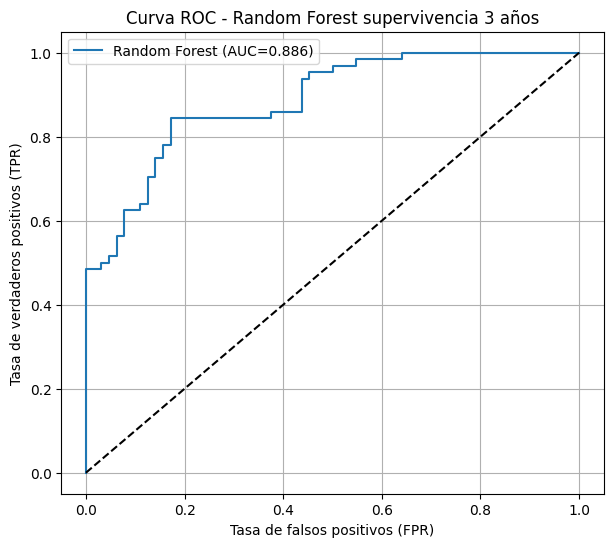

In [65]:
# Definir Random Forest con parámetros ajustados
rf = RandomForestClassifier(n_estimators=300, random_state=42, min_samples_split=5, min_samples_leaf=1, max_features=0.3, max_depth=None, bootstrap=False)

# Evaluacion
auc_scores, y_test, y_proba = evaluar_modelo(rf, X, y, cv)
print(f"AUC ROC promedio Random Forest para supervivencia a 3 años: {np.mean(auc_scores):.4f} ± {np.std(auc_scores):.4f}")

# Grafica ROC para primer fold
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Random Forest (AUC={auc_scores[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Random Forest supervivencia 3 años')
plt.legend()
plt.grid(True)
plt.show()

AUC ROC promedio XGBoost: 0.8374 ± 0.0119


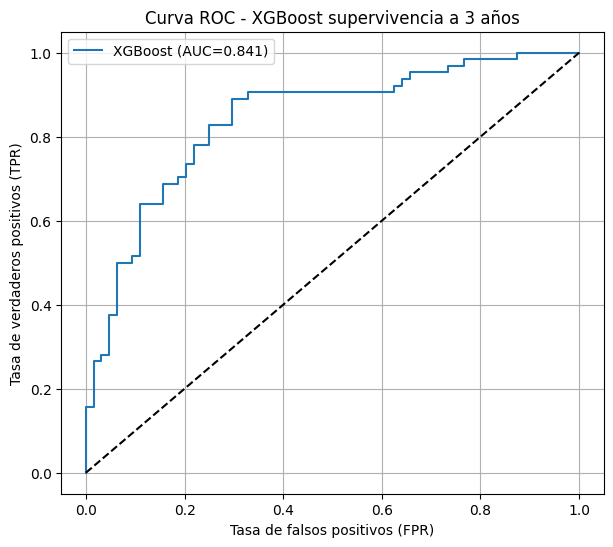

In [66]:
# Definir modelo XGBoost
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    colsample_bytree=0.6,
    gamma=0,
    random_state=42
)

# Evaluar XGBoost
auc_xgb, y_test_xgb, y_proba_xgb = evaluar_modelo(xgb_clf, X, y, cv)
print(f"AUC ROC promedio XGBoost: {np.mean(auc_xgb):.4f} ± {np.std(auc_xgb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_xgb, y_proba_xgb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'XGBoost (AUC={auc_xgb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - XGBoost supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()


AUC ROC promedio Gradient Boosting: 0.8735 ± 0.0220


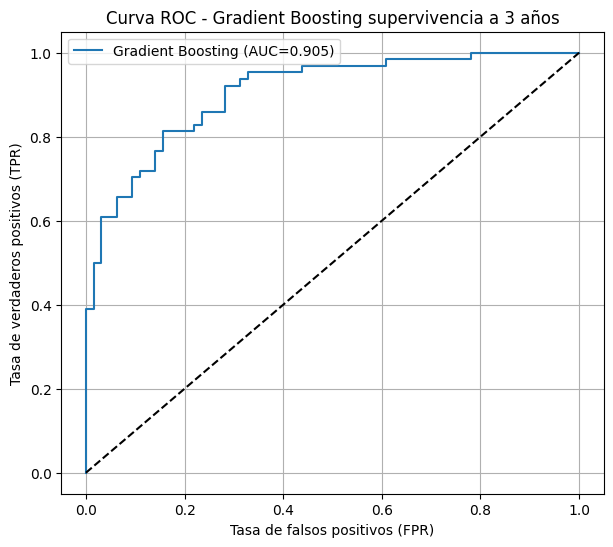

In [67]:
# Definir modelo Gradient Boosting
gb_clf = GradientBoostingClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.2,
    subsample=1.0,
    random_state=42,
    max_features= 'sqrt',
    min_samples_leaf=2,
    min_samples_split=5
)

# Evaluar Gradient Boosting
auc_gb, y_test_gb, y_proba_gb = evaluar_modelo(gb_clf, X, y, cv)
print(f"AUC ROC promedio Gradient Boosting: {np.mean(auc_gb):.4f} ± {np.std(auc_gb):.4f}")

# Graficar curva ROC último fold
fpr, tpr, _ = roc_curve(y_test_gb, y_proba_gb)
plt.figure(figsize=(7,6))
plt.plot(fpr, tpr, label=f'Gradient Boosting (AUC={auc_gb[-1]:.3f})')
plt.plot([0,1], [0,1], 'k--')
plt.xlabel('Tasa de falsos positivos (FPR)')
plt.ylabel('Tasa de verdaderos positivos (TPR)')
plt.title('Curva ROC - Gradient Boosting supervivencia a 3 años')
plt.legend()
plt.grid(True)
plt.show()